<a href="https://colab.research.google.com/github/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes/blob/dataset-2-Diabetes-Prediction-Processing/notebooks/Diabetes_Prediction_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

##
## Diabetes Prediction Dataset EDA & Preprocessing Pipeline

**Dataset:** Diabetes Prediction Dataset (iammustafatz) - Kaggle

**Author:** Tamika Andrews

</center>



---
### About this notebook
This notebook covers two stages of the project pipeline for the Diabetes Prediction dataset:

1. **Exploratory Data Analysis (EDA)** — understanding the structure, distributions, class balance, and feature relationships in the raw dataset before any modifications are made.
2. **Preprocessing Pipeline** — cleaning, encoding, resampling, and splitting the data into training and test sets ready for modelling.

The dataset contains medical and demographic data for 100,000 patients. The target variable is `diabetes` - a binary label where **1 = diabetic** and **0 = not diabetic**.

This is one of three datasets used in our comparative study.

---




## Part 1: Exploratory Data Analysis (EDA)
---

### Step 1 - Imports & Setup
We begin by importing all libraries needed for data loading, numerical operations, and visualisation. These libraries will be used throughout both the EDA and preprocessing sections of this notebook.

| Library | Purpose |
|---|---|
| pandas | Data loading and manipulation |
| numpy | Numerical operations |
| matplotlib | Visualisation |
| seaborn | Statistical visualisation |

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os



---


### Step 2 - Clone Repository & Load Dataset
The dataset is stored in the project GitHub repository under `data/raw/`. We first clone the repository into the Colab environment to make the data accessible, then load it into a pandas DataFrame.

We load the Diabetes Prediction CSV file into a pandas DataFrame. A try/except block is used to catch any file path errors early. The first 10 rows are displayed to visually confirm the data loaded correctly and to get an initial feel for the structure and feature values.

In [42]:
path = "data/raw/diabetes_prediction_dataset.csv"
try:
    df = pd.read_csv(path)
    print(" Diabetes Prediction Dataset loaded successfully")
except Exception as e:
    print(f"Failed to load dataset: {e}")
df.head(10)


 Diabetes Prediction Dataset loaded successfully


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0




---

### Step 3 - Shape & Data Types
Before any analysis, we confirm the exact dimensions of the dataset and the data type of each column. This tells us which columns are numeric and which are categorical, which directly informs our preprocessing decisions later.

In [32]:
print("-" * 30)
print(" Shape & Data Types")
print("-" * 30)
print(f"\n  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print("\nData Types:")
print(df.dtypes)

------------------------------
 Shape & Data Types
------------------------------

  Rows    : 100,000
  Columns : 9

Data Types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object




---
### Step 4 - Categorical Columns & Null Value Check
We identify which columns are categorical and which are numerical. We also check for null values across all columns.

In [45]:
import numpy as np
import pandas as pd

print("-" * 50)
print(" Data Quality Check & Column Summary")
print("-" * 50)

#handle invalid medical zeros (bmi, HbA1c, gluecose)
invalid_zero_cols = ['bmi', 'HbA1c_level', 'blood_glucose_level']
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

#identify column types
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# print categorical summary
print("\nCategorical Columns")
for col in categorical_cols:
    print(f"  {col}: {df[col].unique()}")

#print numerical summary
print(f"\nNumerical Column Statistics")
print(df[numerical_cols].describe().round(2))

#print final null counts
print(f"\nNull Values after processing zeros")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No nulls found.")
print(f"Total nulls in dataset: {df.isnull().sum().sum()}")

--------------------------------------------------
 Data Quality Check & Column Summary
--------------------------------------------------

Categorical Columns
  gender: ['Female' 'Male' 'Other']
  smoking_history: ['never' 'No Info' 'current' 'former' 'ever' 'not current']

Numerical Column Statistics
             age  hypertension  heart_disease        bmi  HbA1c_level  \
count  100000.00     100000.00      100000.00  100000.00    100000.00   
mean       41.89          0.07           0.04      27.32         5.53   
std        22.52          0.26           0.19       6.64         1.07   
min         0.08          0.00           0.00      10.01         3.50   
25%        24.00          0.00           0.00      23.63         4.80   
50%        43.00          0.00           0.00      27.32         5.80   
75%        60.00          0.00           0.00      29.58         6.20   
max        80.00          1.00           1.00      95.69         9.00   

       blood_glucose_level   diabetes 

checking duplicates

In [34]:
print("-" * 50)
print("Duplicate Detection")
print("-" * 50)
print(f"Number of duplicate rows found: {df.duplicated().sum()}")
print(f"Percentage of dataset that is redundant: {(df.duplicated().sum() / len(df)) * 100:.2f}%")

--------------------------------------------------
Duplicate Detection
--------------------------------------------------
Number of duplicate rows found: 3854
Percentage of dataset that is redundant: 3.85%




---


### Step 5 — Class Distribution
We examine the distribution of the target variable `diabetes` to understand how balanced the dataset is. Class imbalance is a critical issue in medical classification tasks. If one class dominates, models tend to simply predict the majority class and still achieve high accuracy while completely failing to detect the minority class (diabetic patients).

In [35]:
print("-" * 31)
print(" Class Distribution")
print("-" * 31)

class_counts = df["diabetes"].value_counts()
class_pct = df["diabetes"].value_counts(normalize=True) * 100

print(pd.DataFrame({"Count": class_counts, "Percentage (%)": class_pct.round(2)}))

-------------------------------
 Class Distribution
-------------------------------
          Count  Percentage (%)
diabetes                       
0         91500            91.5
1          8500             8.5


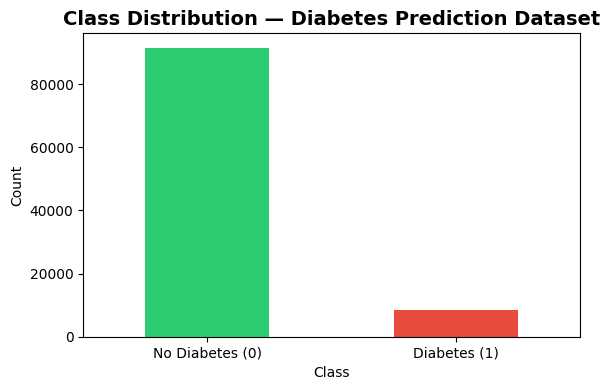

In [36]:
fig, ax = plt.subplots(figsize=(6, 4))
df["diabetes"].value_counts().plot(kind="bar", color=["#2ECC71", "#E74C3C"], ax=ax)

ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"], rotation=0)
ax.set_title("Class Distribution — Diabetes Prediction Dataset", fontsize=14, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("class_distribution_diabetes_prediction.png", dpi=150)
plt.show()



---


### Step 6 - Correlation Analysis
To compute correlations, all columns must be numeric. We create a copy of the DataFrame (`df_encoded`) and apply label encoding to the categorical columns using `pd.factorize()`.


In [37]:
df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

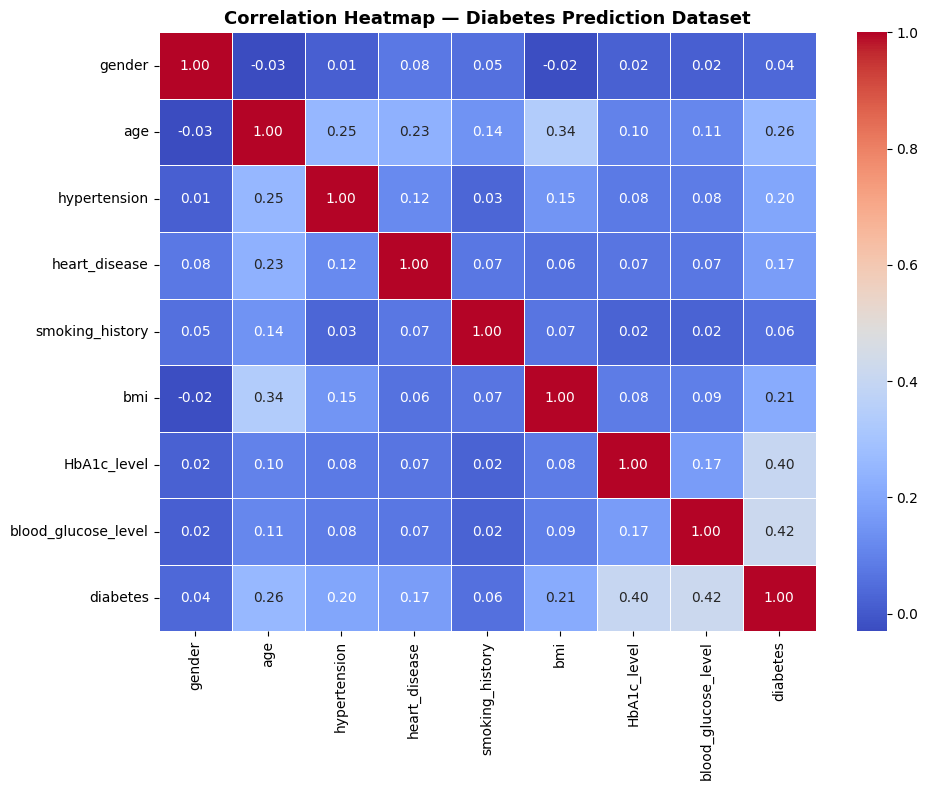

In [38]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Diabetes Prediction Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap_diabetes_prediction.png', dpi=150)
plt.show()



---


### Step 7 — Categorical Feature Distributions
We visualise the value counts for each categorical column. This tells us whether any category dominates, whether rare categories exist that might cause issues during encoding, and helps us make informed decisions about how to handle `No Info` in `smoking_history`.

ipeline part ig


In [39]:
df = df.drop_duplicates().reset_index(drop=True)

print(f"Duplicates removed. New dataset shape: {df.shape}")

Duplicates removed. New dataset shape: (96146, 9)


In [40]:
print("-" * 50)
print(" One-Hot Encoding - Gender & Smoking History")
print("-" * 50)

cols_to_encode = ["gender", "smoking_history"]

existing_cols = [col for col in cols_to_encode if col in df.columns]

if not existing_cols:
    print("Original columns not found. They might already be encoded!")
else:
    for col in existing_cols:
        print(f"Processing: {col}")
        print(f"  Unique values: {df[col].unique()}")
        print(f"  Value counts:\n{df[col].value_counts()}\n")

df = pd.get_dummies(df, columns=cols_to_encode, drop_first=False)

new_cols = [c for c in df.columns if any(sub in c for sub in cols_to_encode)]
print("-" * 50)
print(f"New columns created: {new_cols}")
print(f"Shape after encoding: {df.shape}")
print("-" * 50)

--------------------------------------------------
 One-Hot Encoding - Gender & Smoking History
--------------------------------------------------
Processing: gender
  Unique values: ['Female' 'Male' 'Other']
  Value counts:
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

Processing: smoking_history
  Unique values: ['never' 'No Info' 'current' 'former' 'ever' 'not current']
  Value counts:
smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

--------------------------------------------------
New columns created: ['gender_Female', 'gender_Male', 'gender_Other', 'smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']
Shape after encoding: (96146, 16)
--------------------------------------------------


In [41]:
path = "data/cleaned"

try:
    if not os.path.exists(path):
        os.makedirs(path)

    df.to_csv(f"{path}/diabetes_prediction_dataset_cleaned.csv", index=False)
    print(" Cleaned dataset saved successfully")

except Exception as e:
    print(f"Failed to save dataset: {e}")

 Cleaned dataset saved successfully
